# 门控循环单元（GRU）
:label:`sec_gru`

在 :numref:`sec_bptt`中，
我们讨论了如何在循环神经网络中计算梯度，
以及**矩阵连续乘积可以导致梯度消失或梯度爆炸**的问题。
下面我们简单思考一下这种梯度异常在实践中的意义：

* 我们可能会遇到这样的情况：**早期观测值对预测所有未来观测值具有非常重要的意义**。
  考虑一个极端情况，其中第一个观测值包含一个校验和，
  目标是在序列的末尾辨别校验和是否正确。
  在这种情况下，第一个词元的影响至关重要。
  我们希望有某些机制能够在一个记忆元里存储重要的早期信息。
  如果没有这样的机制，我们将不得不给这个观测值指定一个非常大的梯度，
  因为它会影响所有后续的观测值。
* 我们可能会遇到这样的情况：一些词元没有相关的观测值。
  例如，在对网页内容进行情感分析时，
  可能有一些辅助HTML代码与网页传达的情绪无关。
  我们希望有一些机制来*跳过*隐状态表示中的此类词元。
* 我们可能会遇到这样的情况：序列的各个部分之间存在逻辑中断。
  例如，书的章节之间可能会有过渡存在，
  或者证券的熊市和牛市之间可能会有过渡存在。
  在这种情况下，最好有一种方法来*重置*我们的内部状态表示。

在学术界已经提出了许多方法来解决这类问题。
其中最早的方法是"长短期记忆"（long-short-term memory，LSTM）
 :cite:`Hochreiter.Schmidhuber.1997`，
我们将在 :numref:`sec_lstm`中讨论。
门控循环单元（gated recurrent unit，GRU）
 :cite:`Cho.Van-Merrienboer.Bahdanau.ea.2014`
是一个稍微简化的变体，通常能够提供同等的效果，
并且计算 :cite:`Chung.Gulcehre.Cho.ea.2014`的速度明显更快。
由于门控循环单元更简单，我们从它开始解读。

## 门控隐状态

门控循环单元与普通的循环神经网络之间的关键区别在于：
前者**支持隐状态的门控**。
这意味着模型有专门的机制来确定应该*何时更新隐状态*，
以及应该*何时重置隐状态*。
这些机制是可学习的，并且能够解决了上面列出的问题。
例如，如果第一个词元非常重要，
模型将学会在第一次观测之后不更新隐状态。
同样，模型也可以学会跳过不相关的临时观测。
最后，模型还将学会在需要的时候重置隐状态。
下面我们将详细讨论各类门控。

### 重置门和更新门

我们首先介绍*重置门*（reset gate）和*更新门*（update gate）。
我们把它们**设计成$(0, 1)$区间中的向量**，
这样我们就可以进行**凸组合**。
>重置门允许我们控制“可能还想记住”的*过去状态的数量*；
>更新门将允许我们控制新状态中有多少个是*旧状态的副本*。

我们从构造这些门控开始。 :numref:`fig_gru_1`
描述了门控循环单元中的重置门和更新门的输入，
输入是由**当前时间步的输入和前一时间步的隐状态**给出。
两个门的输出是由**使用sigmoid激活函数的两个全连接层**给出。

![在门控循环单元模型中计算重置门和更新门](../img/gru-1.svg)
:label:`fig_gru_1`

我们来看一下门控循环单元的数学表达。
对于给定的时间步$t$，假设输入是一个小批量
$\mathbf{X}_t \in \mathbb{R}^{n \times d}$
（样本个数$n$，输入个数$d$），
上一个时间步的隐状态是
$\mathbf{H}_{t-1} \in \mathbb{R}^{n \times h}$
（隐藏单元个数$h$）。
那么，重置门$\mathbf{R}_t \in \mathbb{R}^{n \times h}$和
更新门$\mathbf{Z}_t \in \mathbb{R}^{n \times h}$的计算如下所示：

$$
\begin{aligned}
\mathbf{R}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xr} + \mathbf{H}_{t-1} \mathbf{W}_{hr} + \mathbf{b}_r),\\
\mathbf{Z}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xz} + \mathbf{H}_{t-1} \mathbf{W}_{hz} + \mathbf{b}_z),
\end{aligned}
$$

其中$\mathbf{W}_{xr}, \mathbf{W}_{xz} \in \mathbb{R}^{d \times h}$
和$\mathbf{W}_{hr}, \mathbf{W}_{hz} \in \mathbb{R}^{h \times h}$是权重参数，
$\mathbf{b}_r, \mathbf{b}_z \in \mathbb{R}^{1 \times h}$是偏置参数。
请注意，在求和过程中会触发广播机制
（请参阅 :numref:`subsec_broadcasting`）。
我们使用sigmoid函数（如 :numref:`sec_mlp`中介绍的）
将输入值转换到区间$(0, 1)$。

### 候选隐状态

接下来，让我们将重置门$\mathbf{R}_t$
与 :eqref:`rnn_h_with_state`
中的常规隐状态更新机制集成，
得到在时间步$t$的*候选隐状态*（candidate hidden state）
$\tilde{\mathbf{H}}_t \in \mathbb{R}^{n \times h}$。

$$\tilde{\mathbf{H}}_t = \tanh(\mathbf{X}_t \mathbf{W}_{xh} + \left(\mathbf{R}_t \odot \mathbf{H}_{t-1}\right) \mathbf{W}_{hh} + \mathbf{b}_h),$$
:eqlabel:`gru_tilde_H`

其中$\mathbf{W}_{xh} \in \mathbb{R}^{d \times h}$
和$\mathbf{W}_{hh} \in \mathbb{R}^{h \times h}$是权重参数，
$\mathbf{b}_h \in \mathbb{R}^{1 \times h}$是偏置项，
符号$\odot$是Hadamard积（按元素乘积）运算符。
在这里，我们使用tanh非线性激活函数*来确保候选隐状态中的值保持在区间$(-1, 1)$中*。

与 :eqref:`rnn_h_with_state`相比，
 :eqref:`gru_tilde_H`中的$\mathbf{R}_t$和$\mathbf{H}_{t-1}$
的元素相乘可以**减少以往状态的影响**。
- 每当重置门$\mathbf{R}_t$中的项接近$1$时，
我们恢复一个如 :eqref:`rnn_h_with_state`中的普通的循环神经网络。
- 对于重置门$\mathbf{R}_t$中所有接近$0$的项，
候选隐状态是以$\mathbf{X}_t$作为输入的多层感知机的结果。
因此，任何预先存在的隐状态都会被*重置*为默认值。

 :numref:`fig_gru_2`说明了应用重置门之后的计算流程。

![在门控循环单元模型中计算候选隐状态](../img/gru-2.svg)
:label:`fig_gru_2`

### 隐状态

上述的计算结果只是候选隐状态，我们仍然需要结合更新门$\mathbf{Z}_t$的效果。
这一步确定新的隐状态$\mathbf{H}_t \in \mathbb{R}^{n \times h}$
在多大程度上来自旧的状态$\mathbf{H}_{t-1}$和
新的候选状态$\tilde{\mathbf{H}}_t$。
更新门$\mathbf{Z}_t$仅需要在
$\mathbf{H}_{t-1}$和$\tilde{\mathbf{H}}_t$
之间进行按元素的*凸组合*就可以实现这个目标。
这就得出了门控循环单元的最终更新公式：

$$\mathbf{H}_t = \mathbf{Z}_t \odot \mathbf{H}_{t-1}  + (1 - \mathbf{Z}_t) \odot \tilde{\mathbf{H}}_t.$$

- 每当更新门$\mathbf{Z}_t$接近$1$时，模型就倾向只保留旧状态。
此时，来自$\mathbf{X}_t$的信息基本上被忽略，
从而有效地跳过了依赖链条中的时间步$t$。
- 相反，当$\mathbf{Z}_t$接近$0$时，
新的隐状态$\mathbf{H}_t$就会接近候选隐状态$\tilde{\mathbf{H}}_t$。
这些设计可以帮助我们处理循环神经网络中的梯度消失问题，
并更好地捕获时间步距离很长的序列的依赖关系。
例如，如果整个子序列的所有时间步的更新门都接近于$1$，
则无论序列的长度如何，在序列起始时间步的旧隐状态都将很容易保留并传递到序列结束。

 :numref:`fig_gru_3`说明了更新门起作用后的计算流。

![计算门控循环单元模型中的隐状态](../img/gru-3.svg)
:label:`fig_gru_3`

总之，门控循环单元具有以下两个显著特征：

* 重置门有助于捕获序列中的短期依赖关系；
* 更新门有助于捕获序列中的长期依赖关系。



## **1. 更新门和重置门的数学表达式都是一样的，网络怎么判断哪个用于更新和哪个用于重置？还是说这个区别是人为定义的？**

### ✅ 简短回答：
> **结构相同 ≠ 功能相同**。虽然更新门（update gate）和重置门（reset gate）的**计算形式完全一致**（都是线性变换 + sigmoid），但它们**作用的位置不同、参数独立、训练目标不同**，因此功能完全不同。这种“分工”不是人为硬编码的，而是通过**独立的可学习参数**和**在计算图中的不同用途**自然形成的。

---

### 🔍 详细解释：

#### （1）**数学形式相同，但参数独立**
- 重置门：  
  $$\mathbf{R}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xr} + \mathbf{H}_{t-1} \mathbf{W}_{hr} + \mathbf{b}_r)$$
- 更新门：  
  $$\mathbf{Z}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xz} + \mathbf{H}_{t-1} \mathbf{W}_{hz} + \mathbf{b}_z)$$

虽然结构一样，但：
- $\mathbf{W}_{xr} \neq \mathbf{W}_{xz}$,
- $\mathbf{W}_{hr} \neq \mathbf{W}_{hz}$,
- $\mathbf{b}_r \neq \mathbf{b}_z$.

这些参数**从零开始随机初始化，通过反向传播独立学习**。梯度会根据它们在后续计算中的作用，自动调整各自的行为。

#### （2）**在计算图中扮演不同角色**
- **重置门 $\mathbf{R}_t$** 只出现在**候选隐状态 $\tilde{\mathbf{H}}_t$** 的计算中，用于控制“是否遗忘过去”。
- **更新门 $\mathbf{Z}_t$** 出现在**最终隐状态 $\mathbf{H}_t$** 的计算中（见下文），用于控制“新旧信息如何混合”。

最终隐状态为：
$$
\mathbf{H}_t = (1 - \mathbf{Z}_t) \odot \mathbf{H}_{t-1} + \mathbf{Z}_t \odot \tilde{\mathbf{H}}_t
$$

→ 所以，**网络通过损失函数的梯度回传，自动学会**：
- 让 $\mathbf{R}_t$ 在需要“清空历史记忆”时趋近于 0；
- 让 $\mathbf{Z}_t$ 在需要“保留旧状态”时趋近于 0，或在需要“采纳新信息”时趋近于 1。

> ✅ **结论**：这不是人为硬性规定“这个叫更新门、那个叫重置门”，而是**架构设计 + 参数分离 + 梯度驱动**共同导致的功能分化。




## **2. 为什么候选隐藏状态中要使用 Hadamard 积（$\odot$）而不是普通矩阵乘法？这对隐状态更新有什么意义？**

### ✅ 简短回答：
> **Hadamard 积（逐元素相乘）允许对隐状态的每个维度独立地进行“重置”**，而矩阵乘法则会混合所有维度，破坏局部可控性。这是实现“选择性遗忘”的关键。


### 🔍 详细解释：

#### （1）**Hadamard 积的作用：按维度门控**
$$
\left(\mathbf{R}_t \odot \mathbf{H}_{t-1}\right)
$$
- $\mathbf{R}_t[i, j] \in (0,1)$ 控制第 $i$ 个样本的第 $j$ 个隐单元是否保留历史信息。
- 若 $\mathbf{R}_t[i, j] \approx 0$，则该维度的历史被“清零”；
- 若 $\mathbf{R}_t[i, j] \approx 1$，则完全保留。

→ 这实现了**细粒度的、维度级别的记忆控制**。

#### （2）**如果用矩阵乘法会怎样？**
假设你错误地写成：
$$
\mathbf{R}_t \mathbf{H}_{t-1} \quad \text{（维度不匹配！）}
$$
- $\mathbf{R}_t \in \mathbb{R}^{n \times h}$, $\mathbf{H}_{t-1} \in \mathbb{R}^{n \times h}$，
- 矩阵乘法要求内维匹配，但这里都是 $(n,h)$，无法直接相乘。
- 即使强行转置（如 $\mathbf{R}_t^\top \mathbf{H}_{t-1}$），结果会是 $h \times h$，**混合了所有样本和所有维度的信息**，完全失去“按样本、按维度独立控制”的能力。

#### （3）**工程意义：解耦与并行**
- Hadamard 积是**element-wise**操作，可高度并行（GPU 友好）。
- 它保持了输入张量的形状 $(n, h)$，便于后续与 $\mathbf{W}_{hh}$ 做矩阵乘。

> ✅ **本质**：Hadamard 积是实现“**门控机制**”的标准工具——它让一个 sigmoid 输出（门）去**调制**另一个信号的强度，而不改变其结构。





## **3. 什么是凸组合？什么是门控单元的凸组合？它与自适应滤波、卡尔曼滤波有何异同？**

### ✅ 首先：什么是凸组合（Convex Combination）？

给定两个向量 $\mathbf{a}, \mathbf{b}$，若：
$$
\mathbf{c} = \alpha \mathbf{a} + (1 - \alpha) \mathbf{b}, \quad \text{其中 } \alpha \in [0,1]
$$
则称 $\mathbf{c}$ 是 $\mathbf{a}$ 和 $\mathbf{b}$ 的**凸组合**。

- 凸组合的结果**不会超出 $\mathbf{a}$ 和 $\mathbf{b}$ 的“范围”**（在向量空间中）。
- 所有系数非负且和为 1。


### ✅ GRU 中的凸组合

GRU 的最终隐状态为：
$$
\mathbf{H}_t = (1 - \mathbf{Z}_t) \odot \mathbf{H}_{t-1} + \mathbf{Z}_t \odot \tilde{\mathbf{H}}_t
$$

- 对每个元素 $j$：
  $$
  H_t^{(j)} = (1 - Z_t^{(j)}) \cdot H_{t-1}^{(j)} + Z_t^{(j)} \cdot \tilde{H}_t^{(j)}
  $$
- 因为 $Z_t^{(j)} \in (0,1)$，所以这是一个**逐元素的凸组合**。

→ **物理意义**：在“保持旧状态”和“采纳新候选状态”之间做**软切换**（soft switch）。

---

### 🔍 与自适应滤波、卡尔曼滤波的比较

| 特性 | GRU（门控凸组合） | 卡尔曼滤波（KF） | 自适应滤波（如 LMS） |
|------|------------------|------------------|---------------------|
| **目标** | 序列建模、预测 | 状态估计（含噪声） | 系统辨识、噪声抑制 |
| **组合形式** | $\mathbf{H}_t = (1-z)\mathbf{H}_{t-1} + z \tilde{\mathbf{H}}_t$ | $\hat{x}_t = (1-K_t)\hat{x}_{t \|t-1} + K_t z_t$ | $w_{t+1} = w_t + \mu e_t x_t$ |
| **权重来源** | **数据驱动**，由神经网络学习（非线性） | **模型驱动**，由系统动态方程和噪声协方差解析计算（线性高斯最优） | **误差驱动**，基于瞬时梯度（线性） |
| **非线性** | ✅ 支持（tanh, sigmoid） | ❌ 经典 KF 是线性的（扩展 KF/EKF 可处理非线性） | ❌ 通常是线性的 |
| **参数学习** | 端到端训练（反向传播） | 需要已知系统模型和噪声统计 | 步长 $\mu$ 需手动调或自适应 |
| **凸组合？** | ✅ 是（逐元素） | ✅ 是（卡尔曼增益 $K_t \in [0,1]$） | ❌ 不是组合，是迭代更新 |

#### 🌟 本质异同：

- **相同点**：
  - 都在“旧估计”和“新观测/预测”之间做加权融合。
  - 权重（门/增益）决定信任程度。
  - 都可视为**动态记忆机制**。

- **不同点**：
  - **卡尔曼滤波**是**贝叶斯最优估计器**（在线性高斯假设下），有严格的概率解释。
  - **GRU**是**启发式、数据驱动的黑箱模型**，没有显式的概率模型，但通过大量数据学习到类似“自适应增益”的行为。
  - **GRU 的门是上下文感知的**：$z_t = f(x_t, h_{t-1})$，而 KF 的增益只依赖于预设的噪声模型。

> 💡 **有趣观点**：GRU 可以看作是一种**非线性、数据驱动的“类卡尔曼”更新机制**，但它不假设任何生成模型，而是直接从任务损失中学习如何融合信息。

## 从零开始实现

为了更好地理解门控循环单元模型，我们从零开始实现它。
首先，我们读取 :numref:`sec_rnn_scratch`中使用的时间机器数据集：


In [2]:
import torch
from torch import nn
from myd2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

### [**初始化模型参数**]

下一步是初始化模型参数。
我们从标准差为$0.01$的高斯分布中提取权重，
并将偏置项设为$0$，超参数`num_hiddens`定义隐藏单元的数量，
实例化与更新门、重置门、候选隐状态和输出层相关的所有权重和偏置。


In [3]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device)*0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xz, W_hz, b_z = three()  # 更新门参数
    W_xr, W_hr, b_r = three()  # 重置门参数
    W_xh, W_hh, b_h = three()  # 候选隐状态参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

### 定义模型

现在我们将[**定义隐状态的初始化函数**]`init_gru_state`。
与 :numref:`sec_rnn_scratch`中定义的`init_rnn_state`函数一样，
此函数返回一个形状为（批量大小，隐藏单元个数）的张量，张量的值全部为零。


In [4]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

现在我们准备[**定义门控循环单元模型**]，
模型的架构与基本的循环神经网络单元是相同的，
只是权重更新公式更为复杂。


In [5]:
def gru(inputs, state, params):
    W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        Z = torch.sigmoid((X @ W_xz) + (H @ W_hz) + b_z)
        R = torch.sigmoid((X @ W_xr) + (H @ W_hr) + b_r)
        H_tilda = torch.tanh((X @ W_xh) + ((R * H) @ W_hh) + b_h)
        H = Z * H + (1 - Z) * H_tilda
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

### [**训练**]与预测

训练和预测的工作方式与 :numref:`sec_rnn_scratch`完全相同。
训练结束后，我们分别打印输出训练集的困惑度，
以及前缀“time traveler”和“traveler”的预测序列上的困惑度。


困惑度 1.1, 14695.6 词元/秒 cuda:0
time traveller proceeded anyreal body must have extension in fou
travelleryou can show black is white by argument said filby


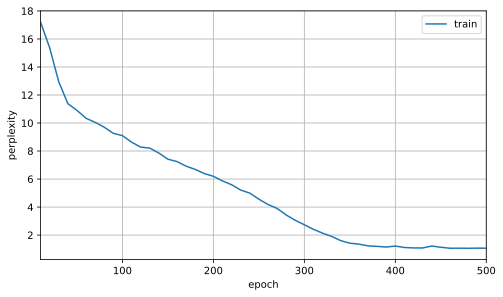

In [6]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_params,
                            init_gru_state, gru)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

## [**简洁实现**]

高级API包含了前文介绍的所有配置细节，
所以我们可以直接实例化门控循环单元模型。
这段代码的运行速度要快得多，
因为它使用的是编译好的运算符而不是Python来处理之前阐述的许多细节。


困惑度 1.0, 148202.2 词元/秒 cuda:0
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


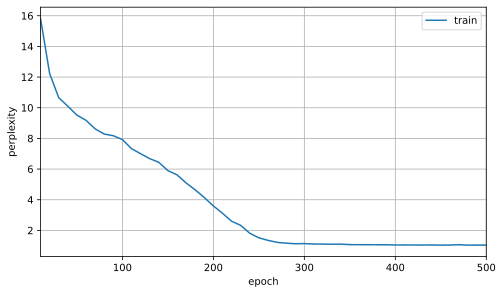

In [7]:
num_inputs = vocab_size
gru_layer = nn.GRU(num_inputs, num_hiddens)
model = d2l.RNNModel(gru_layer, len(vocab))
model = model.to(device)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

## 小结

* 门控循环神经网络可以更好地捕获时间步距离很长的序列上的依赖关系。
* 重置门有助于捕获序列中的短期依赖关系。
* 更新门有助于捕获序列中的长期依赖关系。
* 重置门打开时，门控循环单元包含基本循环神经网络；更新门打开时，门控循环单元可以跳过子序列。

## 练习

1. 假设我们只想使用时间步$t'$的输入来预测时间步$t > t'$的输出。对于每个时间步，重置门和更新门的最佳值是什么？
1. 调整和分析超参数对运行时间、困惑度和输出顺序的影响。
1. 比较`rnn.RNN`和`rnn.GRU`的不同实现对运行时间、困惑度和输出字符串的影响。
1. 如果仅仅实现门控循环单元的一部分，例如，只有一个重置门或一个更新门会怎样？


[Discussions](https://discuss.d2l.ai/t/2763)


1. 假设我们只想使用时间步$t'$的输入来预测时间步$t > t'$的输出。对于每个时间步，重置门和更新门的最佳值是什么？

---

## ✅ 正确答案的核心思想：

> **若只想用时间步 $t'$ 的输入 $\mathbf{X}_{t'}$ 来预测 $t > t'$ 的输出，则：**
> - **在 $t = t'+1$ 时**：重置门 $\mathbf{R}_{t'+1} \to \mathbf{0}$（彻底遗忘 $t'$ 之前的隐状态），更新门 $\mathbf{Z}_{t'+1} \to \mathbf{1}$（完全采纳新候选状态）；
> - **在 $t > t'+1$ 时**：重置门 $\mathbf{R}_t \to \mathbf{1}$（保留历史），更新门 $\mathbf{Z}_t \to \mathbf{0}$（冻结状态，不再更新）。

但这在标准 GRU 中**无法完美实现“冻结”**，因为 GRU 每一步都必须计算新状态。更合理的做法是：**让模型在 $t'$之后仅依赖  $\mathbf{X}_{t^{\prime}}$ 编码的信息进行自维持演化**。

不过，若严格按题意“**只用 $t'$ 的输入**”，最干净的做法其实是：
> **在 $t'$ 时刻编码信息后，后续所有时间步都不再接受新输入（即 $\mathbf{X}_t = \mathbf{0},\, \forall t > t'$）**，并让 GRU 自然传播该记忆。

但题目假设“每个时间步都有输入”，所以我们聚焦于**如何通过门控实现“只记住 $t'$”**。

---

## 🔍 分阶段分析（假设 $t'$ 已知）

### 阶段 1：$t < t'$
- 目标：正常处理，无需特殊操作。
- 门值：任意（由数据决定）。

### 阶段 2：$t = t'$
- 目标：**充分编码 $\mathbf{X}_{t'}$ 到隐状态中**。
- 理想门控：
  - $\mathbf{R}_{t'} \approx \mathbf{1}$：保留之前状态（可选，若之前无关则 $\mathbf{R}\to 0$）
  - $\mathbf{Z}_{t'} \approx \mathbf{1}$：让 $\tilde{\mathbf{H}}_{t'}$ 完全主导 $\mathbf{H}_{t'}$

> 实际上，我们希望 $\mathbf{H}_{t'}$ 成为 $\mathbf{X}_{t'}$ 的良好表示。

### 阶段 3：$t = t'+1$
- 目标：**彻底切断与 $t'-1$ 及更早状态的联系**，只基于 $\mathbf{H}_{t'}$ 和 $\mathbf{X}_{t'+1}$ 计算。
- 但注意：$\mathbf{X}_{t'+1}$ 是“不该用”的输入！
- 所以更关键的是：**让模型忽略 $t > t'$ 的输入**。

→ 这引出一个矛盾：**GRU 默认每一步都使用当前输入 $\mathbf{X}_t$**。

---

## 🛠 如何真正实现“只用 $t'$ 的输入”？

### 方法一：**预处理输入序列（推荐）**
- 将所有 $t > t'$ 的输入设为零或特殊标记：
  $$
  \mathbf{X}_t = 
  \begin{cases}
    \text{原始输入}, & t = t' \\
    \mathbf{0}, & t \ne t'
  \end{cases}
  $$
- 然后正常运行 GRU。
- 此时，GRU 会在 $t'$ 编码信息，之后靠内部动力学传播。

✅ 这是最简单、最可靠的方式，**无需修改 GRU 结构**。

---

### 方法二：**通过门控“屏蔽”后续输入（理论可行，实践困难）**

要让 $t > t'$ 时 **忽略 $\mathbf{X}_t$**，需满足：
1. 在计算 $\tilde{\mathbf{H}}_t$ 时，$\mathbf{X}_t \mathbf{W}_{xh} \approx \mathbf{0}$
2. 或者让 $\mathbf{R}_t \to \mathbf{0}$，使得 $\tilde{\mathbf{H}}_t \approx \tanh(\mathbf{X}_t \mathbf{W}_{xh} + \mathbf{b}_h)$，但这仍包含 $\mathbf{X}_t$！

→ **无法通过门控完全消除 $\mathbf{X}_t$ 的影响**，因为 $\mathbf{X}_t$ 直接出现在 $\tilde{\mathbf{H}}_t$ 的线性项中。

除非你修改 GRU 公式，例如引入“输入门”，但标准 GRU 没有。

---

### 方法三：**在 $t'$ 后强制隐状态不变（模拟“记忆保持”）**

若希望 $\mathbf{H}_t = \mathbf{H}_{t'}$ 对所有 $t > t'$ 成立，则需：
$$
\mathbf{H}_t = (1 - \mathbf{Z}_t) \odot \mathbf{H}_{t-1} + \mathbf{Z}_t \odot \tilde{\mathbf{H}}_t = \mathbf{H}_{t-1}
$$
⇒ 要求 $\mathbf{Z}_t \to \mathbf{0}$，且 $\tilde{\mathbf{H}}_t$ 任意（因其被乘 0）。

但 $\tilde{\mathbf{H}}_t$ 仍依赖 $\mathbf{X}_t$，而 $\mathbf{Z}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xz} + \cdots)$ 也依赖 $\mathbf{X}_t$。

→ **只有当 $\mathbf{X}_t = \mathbf{0}$ 时，才容易让 $\mathbf{Z}_t \to \mathbf{0}$**。

---

## ✅ 最佳实践总结

| 目标 | 推荐做法 |
|------|--------|
| **只用 $t'$ 的输入预测未来** | **将 $t \ne t'$ 的输入置零**，然后正常训练/推理 GRU |
| 若必须保留原始输入序列 | 使用 **注意力机制**（如 Transformer），直接让输出只 attend 到 $t'$ |
| 若坚持用 GRU 且不改输入 | 很难完美实现；可尝试在损失函数中加正则，鼓励 $t>t'$ 时 $\mathbf{Z}_t \to 0$，但效果有限 |

---

## ❌ 你原回答的问题

> “使用分段的 candidate hidden state 对于 t' 之前的全部遗忘，对于 t' 之后的全部更新”

- **“t' 之后全部更新”是错误的**：如果不断“更新”，就会引入 $t>t'$ 的新输入信息，违背“只用 $t'$”的要求。
- 正确应是：**在 $t'$ 编码后，后续尽量“不更新”或“只传播已有信息”**。

---

## 💡 延伸思考：这正是 **Encoder-Decoder 架构**解决的问题！

- Encoder 读取整个输入序列（到 $t'$ 为止），输出一个上下文向量 $\mathbf{c}$。
- Decoder 从 $\mathbf{c}$ 开始，**不看新输入**，逐步生成输出。
- GRU 可作为 Encoder 或 Decoder 的单元。

所以，**不要试图用单个 GRU 序列强行实现“只记某一步”**，而是用合适的架构。
